<Figure size 700x500 with 0 Axes>

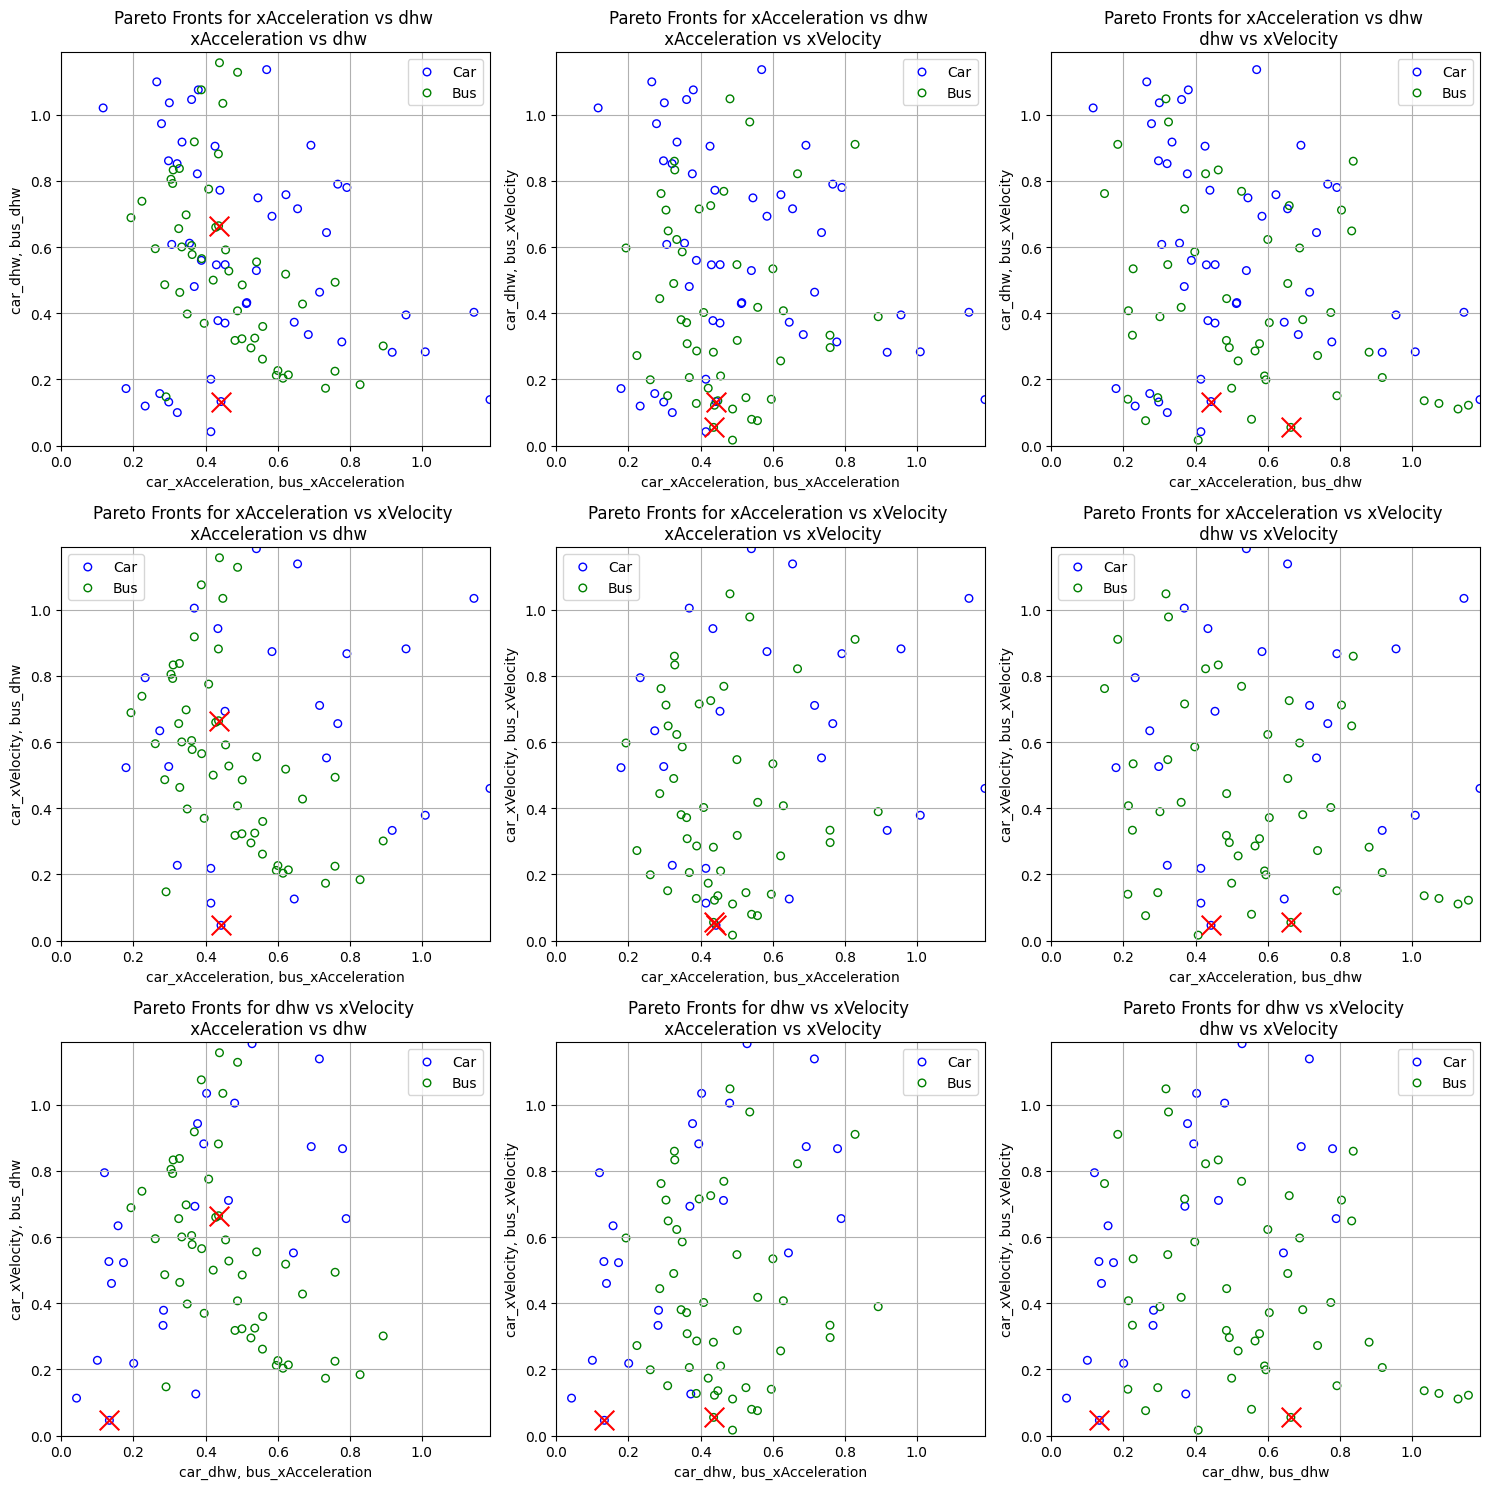

In [30]:

from pymoo.core.problem import ElementwiseProblem
import numpy as np
import time
import random
from task import SUMO_task,pbounds
from pymoo.algorithms.moo.nsga2 import NSGA2
import matplotlib.pyplot as plt
import pickle
from multi_object_optimization import  MooSUMOProblem, SinSUMOProblem


with open('../output/data_cache/nsga2_result.pkl', 'rb') as f:
# with open('../output/data_cache/sms_result.pkl', 'rb') as f:
    res1 = pickle.load(f)
res  = res1

# Assuming `F` and `problem` are already defined
F = res.F
xl, xu = res.problem.bounds()
fig = plt.figure(figsize=(7, 5))
distance_sums = (np.sum(F, axis=1))
ideal_point_index = np.argmin(np.sum(F, axis=1))

# Get the ideal point
ideal_point = F[ideal_point_index]

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
car_fi = ["xAcceleration", "dhw", "xVelocity"]
bus_fi = ["xAcceleration", "dhw", "xVelocity"]

# Flatten the axes array for easier iteration
axes = axes.flatten()
plot_idx = 0
for x, y in [(0, 1), (0, 2), (1, 2)]:
    for x1, y1 in [(3, 4), (3, 5), (4, 5)]:
        ax = axes[plot_idx]
        ax.scatter(F[:, x], F[:, y], s=30, facecolors='none', edgecolors='blue')
        ax.scatter(F[:, x1], F[:, y1], s=30, facecolors='none', edgecolors='green')
        
        # Mark the ideal point
        ax.scatter(ideal_point[x], ideal_point[y], s=200, c='red', marker='x')
        ax.scatter(ideal_point[x1], ideal_point[y1], s=200, c='red', marker='x')
        
        ax.set_xlim([0, max(F[:, 0])])
        ax.set_ylim([0, max(F[:, 0])])
        ax.set_xlabel(f"car_{car_fi[x]}, bus_{bus_fi[x1-3]}")
        ax.set_ylabel(f"car_{car_fi[y]}, bus_{bus_fi[y1-3]}")
        ax.set_title(f"Pareto Fronts for {car_fi[x]} vs {car_fi[y]} \n {bus_fi[x1-3]} vs {bus_fi[y1-3]}")
        ax.legend(["Car", "Bus"])
        ax.grid()
        plot_idx += 1

plt.tight_layout()
plt.show()

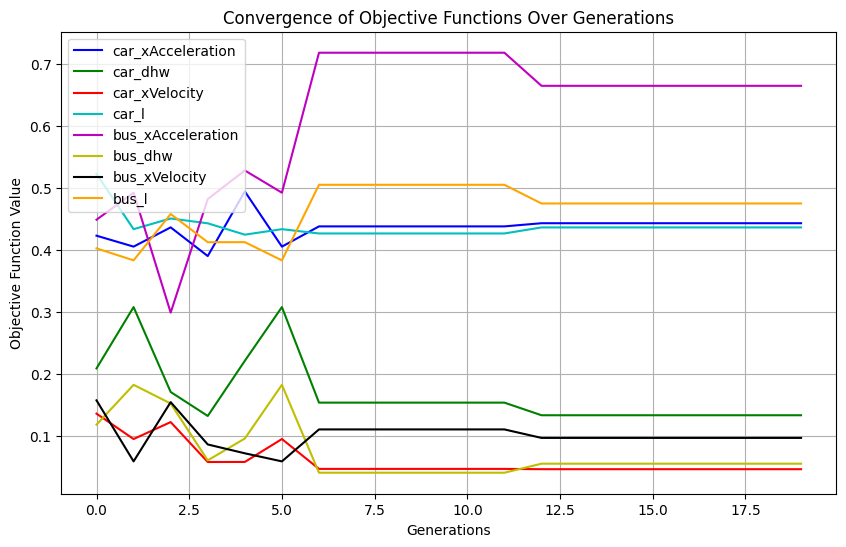

In [34]:

# plot the iteration drop for 6 object in F
history = res.history
n_gen = len(history)

# 初始化保存最佳个体的目标函数值的列表
best_solutions = []

for gen in history:
    opt = gen.opt
    F = opt.get('F')
    # 找到总目标函数值最小的个体索引
    total_obj_values = F.sum(axis=1)
    best_idx = total_obj_values.argmin()
    # 记录该个体的目标函数值
    best_solutions.append(F[best_idx])

# 生成迭代次数的列表
generations = list(range(n_gen))

# 分别提取6个目标函数值
f1_values = [sol[0] for sol in best_solutions]
f2_values = [sol[1] for sol in best_solutions]
f3_values = [sol[2] for sol in best_solutions]
f4_values = [sol[3] for sol in best_solutions]
f5_values = [sol[4] for sol in best_solutions]
f6_values = [sol[5] for sol in best_solutions]
f7_values = [sol[6] for sol in best_solutions]
f8_values = [sol[7] for sol in best_solutions]

# 开始绘制折线图
fig, ax = plt.subplots(figsize=(10, 6))

objectives = ["car_xAcceleration", "car_dhw", "car_xVelocity", "car_l","bus_xAcceleration", "bus_dhw", "bus_xVelocity" , "bus_l"]
values = [f1_values, f2_values, f3_values, f4_values, f5_values, f6_values,f7_values,f8_values]
colors = ["b", "g", "r", "c", "m", "y", "k", "orange"]

for i in range(8):
    ax.plot(generations, values[i], label=objectives[i], color=colors[i])

ax.set_xlabel("Generations")
ax.set_ylabel("Objective Function Value")
ax.set_title("Convergence of Objective Functions Over Generations")
ax.legend()
ax.grid()

plt.show()


In [35]:
from pymoo.core.problem import ElementwiseProblem
import numpy as np
import time
import random
from task import SUMO_task,pbounds
from pymoo.algorithms.moo.nsga2 import NSGA2
import matplotlib.pyplot as plt
import pickle
from multi_object_optimization import  MooSUMOProblem, SinSUMOProblem
Fs = np.array([ind.F for ind in res.history[-1].pop])
sum_F = np.sum(Fs, axis=1)
min_index = np.argmin(sum_F)
min_F = Fs[min_index]
min_X = res.history[-1].pop[min_index].X

# 打印具有最小 F 合计值的个体的参数和 F
print("\n具有最小 F 合计值的个体的参数和 F：")
print("输入参数：", min_X)
print("对应的 F 值：", min_F)
print("F 合计值：", sum_F[min_index]/6)




具有最小 F 合计值的个体的参数和 F：
输入参数： [ 1.56378809  0.21375961  2.55852975  7.00410562  1.58675256  2.31861392
  2.03681777  2.37957763  0.5785197   0.27442354  0.33853038  0.37165458
 11.40554583 11.69094532 19.13353814  1.4389444   0.98664343  0.75307066
  0.41073383  0.73268023  0.40030489  2.40848142 45.12162268 67.5747924
  0.45269134  0.74461199 68.80124309 69.27886043]
对应的 F 值： [0.44285324 0.13313522 0.04611092 0.43607582 0.66448323 0.05499436
 0.09658479 0.47471605]
F 合计值： 0.3914922727542469


In [33]:
def gen_eval_data(min_X):
    param = {key: min_X[i] for i, key in enumerate(pbounds.keys())}
    task = SUMO_task(param)
    res = task.run_task(save=True, gui=False,sim_step=500*30)
# gen_eval_data(min_X)